# Discussion and Implications

## Objective

In this notebook, I build on the exploratory analysis from Notebook 3 by examining broader trends, interpreting what the findings may suggest, and discussing how public search data can inform future research and decision-making. Rather than describing the data again, this notebook focuses on new analyses and the broader implications of the results.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

trends = pd.read_csv("../data/raw/cleaned/google_trends_cleaned.csv")

trends["date"] = pd.to_datetime(trends["date"])

trends.head()

,date,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence,isPartial
0,2019-01-01,11,46,95,82,6,False
1,2019-02-01,10,38,79,84,13,False
2,2019-03-01,10,39,82,90,4,False
3,2019-04-01,12,42,81,85,4,False
4,2019-05-01,12,41,83,83,4,False


## Research Question 1

Which search topics experienced the greatest long-term change between 2019 and 2025?

In [3]:
trends["year"] = trends["date"].dt.year

yearly_average = trends.groupby("year")[
    [
        "domestic violence help",
        "abuse hotline",
        "women's shelter",
        "emotional abuse",
        "teen dating violence"
    ]
].mean()

yearly_average

,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence
year,,,,,
2019,10.750000,39.000000,86.000000,82.250000,4.250000
2020,10.666667,35.916667,70.083333,77.000000,3.333333
2021,11.666667,34.333333,77.333333,77.500000,2.583333
2022,14.250000,36.416667,77.666667,81.833333,3.916667
2023,13.916667,34.750000,74.833333,80.750000,4.000000
2024,14.333333,34.416667,64.416667,77.666667,4.500000
2025,16.000000,32.583333,61.333333,85.083333,4.083333


In [4]:
change = yearly_average.loc[2025] - yearly_average.loc[2019]

change.sort_values(ascending=False)

domestic violence help     5.250000
emotional abuse            2.833333
teen dating violence      -0.166667
abuse hotline             -6.416667
women's shelter          -24.666667
dtype: float64

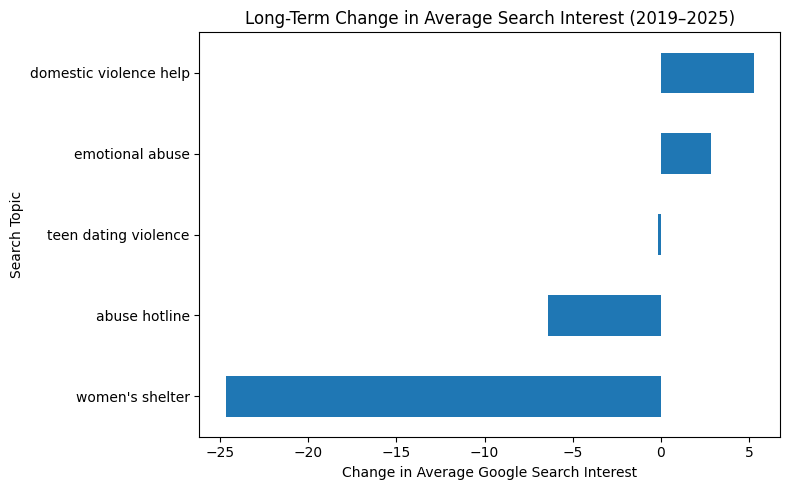

In [5]:
plt.figure(figsize=(8,5))

change.sort_values().plot(kind="barh")

plt.title("Long-Term Change in Average Search Interest (2019–2025)")
plt.xlabel("Change in Average Google Search Interest")
plt.ylabel("Search Topic")

plt.tight_layout()
plt.show()

### Findings

Comparing the average search interest in 2019 and 2025 shows that search topics changed in different ways over the study period. "Domestic violence help" experienced the largest increase in average search interest, while "emotional abuse" also showed a moderate increase. In contrast, searches related to "women's shelter" and "abuse hotline" decreased, and "teen dating violence" remained relatively stable.

These results suggest that public interest in different domestic violence support resources has not changed uniformly over time. Instead, search behavior appears to shift depending on the type of information people are seeking, highlighting how online information needs can evolve over several years.

## Research Question 2

What do these findings suggest about evolving public awareness of domestic violence support resources?

### Discussion

The results from Research Question 1 suggest that interest in different domestic violence support resources has changed over time rather than moving in the same direction. Searches for broader terms such as "domestic violence help" increased, while searches for more specific resources, including "women's shelter" and "abuse hotline," decreased over the study period.

One possible explanation is that the way people search for support online has evolved. Individuals may begin with broader search terms before exploring specific resources, or they may rely on newer online platforms that provide information without requiring searches for traditional services. Increased public discussion of topics such as emotional abuse may also influence the language people use when seeking information.

Although Google Trends cannot explain why these changes occurred, the findings suggest that public search behavior evolves alongside changes in awareness, communication, and access to online information. These results should be interpreted as indicators of broader patterns rather than direct evidence of changes in domestic violence prevalence or service use.

## Research Question 3

Were there periods when multiple domestic violence-related search topics were above their average search interest simultaneously?

In [10]:
topics = [
    "domestic violence help",
    "abuse hotline",
    "women's shelter",
    "emotional abuse",
    "teen dating violence"
]

topic_means = trends[topics].mean()

topic_means

domestic violence help    13.083333
abuse hotline             35.345238
women's shelter           73.095238
emotional abuse           80.297619
teen dating violence       3.809524
dtype: float64

In [11]:
above_average = trends[topics] > topic_means

In [12]:
trends["topics_above_average"] = above_average.sum(axis=1)

trends[["date", "topics_above_average"]].head()

,date,topics_above_average
0,2019-01-01,4
1,2019-02-01,4
2,2019-03-01,4
3,2019-04-01,4
4,2019-05-01,4


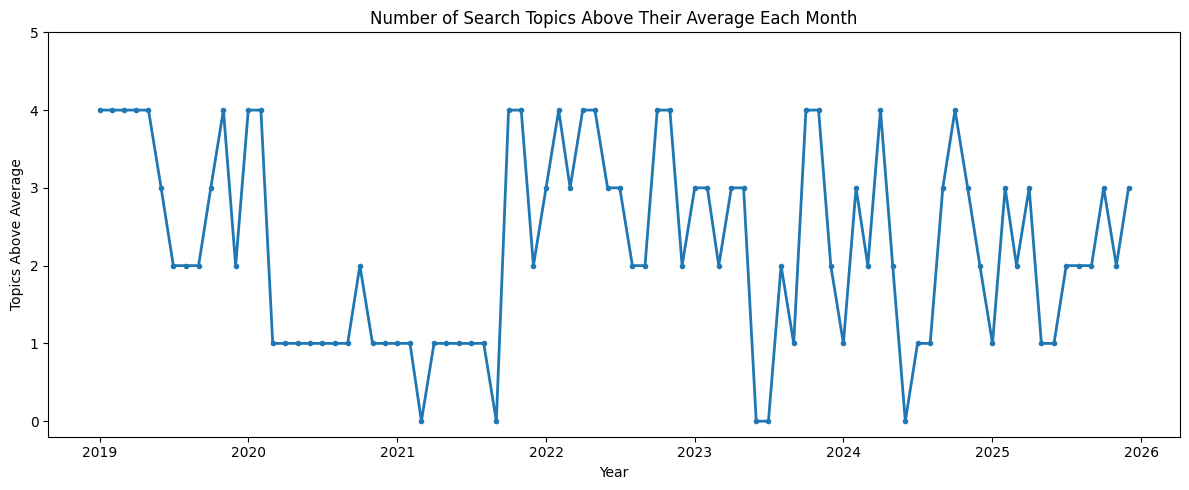

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    trends["date"],
    trends["topics_above_average"],
    marker="o",
    markersize=3,
    linewidth=2
)

plt.title("Number of Search Topics Above Their Average Each Month")
plt.xlabel("Year")
plt.ylabel("Topics Above Average")
plt.yticks(range(0,6))

plt.tight_layout()
plt.show()

In [17]:
top_months = trends.nlargest(10, "topics_above_average").sort_values("date")

top_months[["date", "topics_above_average"]]

,date,topics_above_average
0,2019-01-01,4
1,2019-02-01,4
2,2019-03-01,4
3,2019-04-01,4
4,2019-05-01,4
10,2019-11-01,4
12,2020-01-01,4
13,2020-02-01,4
33,2021-10-01,4
34,2021-11-01,4


### Findings

The analysis found several periods in which multiple domestic violence-related search topics were above their long-term average simultaneously. Although no month had all five search topics above average at once, multiple months—including several during 2019, early 2020, and late 2021—had four topics above their average search interest.

These findings suggest that increases in online search activity often occurred across several support-related topics rather than being limited to a single search term. While this analysis cannot determine the reasons behind these periods of elevated interest, it indicates that broader shifts in online information-seeking behavior may occur across multiple domestic violence support resources at the same time.

## Research Question 4

How could these findings help inform public policy and community outreach efforts?

### Discussion

Although Google Trends does not measure actual incidents of domestic violence or service use, it can provide a useful source of real-time public interest. The analyses in this project suggest that online search behavior changes over time and that multiple support-related topics sometimes experience increased interest simultaneously. These patterns could help organizations identify periods when people may be actively seeking information and support.

For nonprofit organizations, advocacy groups, and public agencies, search trend data could complement existing sources of information when planning awareness campaigns or educational initiatives. For example, identifying periods of increased online interest could help organizations decide when to share resources, promote support services, or expand public outreach efforts.

However, search data should be used alongside other forms of evidence rather than as a replacement for surveys, hotline statistics, or community-based research. Combining multiple data sources can provide a more complete understanding of public needs while reducing the risk of drawing conclusions from search behavior alone.

## Research Question 5

What ethical considerations and limitations should researchers consider when using public search data to study sensitive social issues?

### Discussion

Google Trends provides publicly available, aggregated search data, making it a valuable resource for studying broad patterns in online information-seeking while protecting individual privacy. However, researchers should be careful not to overinterpret search behavior, especially when studying sensitive topics such as domestic violence.

One important limitation is that Google Trends reflects search interest rather than confirmed experiences or incidents. People may search for domestic violence-related topics for many different reasons, including education, news events, school assignments, or personal curiosity. As a result, search data should not be used as direct evidence of the prevalence of domestic violence or the number of people seeking support.

Researchers also have a responsibility to communicate their findings carefully. Search trends can highlight meaningful patterns, but they cannot establish cause-and-effect relationships or explain why changes occur. Using multiple sources of data alongside Google Trends can provide a more complete and responsible understanding of complex social issues.

# Conclusion

This project explored how Google Trends data can be used to examine online search behavior related to domestic violence support resources between 2019 and 2025. Through data collection, cleaning, exploratory analysis, and advanced analysis, the findings showed that search behavior changed over time and that multiple support-related topics occasionally experienced increased interest simultaneously.

While Google Trends cannot explain why these patterns occur or measure real-world experiences directly, it offers a valuable way to study broad trends in public information-seeking behavior. Future research that combines search data with additional public datasets could provide even deeper insights into how people access information and support for complex social issues.